# Notebook 4 — Is the fit any good?

*SWC ENC 2026 · behaviour module*

On synthetic mice we can check a fit against ground truth. On **real** mice we
can't — so we need a way to judge a model by how well it **predicts behavior we
didn't fit it to**. That's this notebook: the ROC curve, the AUC, and
cross-validation. It's the machinery behind Figure 2A.

**In this notebook you will:**
1. See why plain accuracy is misleading when licking is rare.
2. Build a **ROC curve** from scratch and check it against the backend.
3. Understand what the **AUC** means and compute it.
4. Use **cross-validation** to get an honest, non-overfit score.

---
**The paper panel this notebook reproduces**

<img src="../assets/paper/fig2a.png" width="320">

*Fig. 2A — cross-validated model performance (area under the ROC curve) across
sessions. This notebook builds the ROC / AUC / cross-validation machinery behind
that number.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
import swcbehav as sb

def get_Xy(sess):
    # Observable design matrix and per-image bout outcome.
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

# fit_static / predict_prob were built in Notebook 3; import them from the backend.
sess = sb.make_mouse("visual", seed=0)
X, y, cols = get_Xy(sess)
w = sb.fit_static(X, y)
scores = sb.predict_prob(w, X)      # model probability of a bout on each image

## 1. Why not just use accuracy?

Licking bouts are rare — most images have no bout. So a lazy model that predicts
"never lick" is *right* most of the time and yet tells us nothing. Accuracy is
dominated by the majority class.

In [2]:
base_rate = y.mean()
naive_accuracy = 1 - base_rate     # "never lick" is right on every non-bout image
print(f"bouts occur on {base_rate:.1%} of images")
print(f"a 'never lick' model has accuracy {naive_accuracy:.1%} -- and zero value")

bouts occur on 17.9% of images
a 'never lick' model has accuracy 82.1% -- and zero value


## 2. The ROC curve

The model outputs a *probability* per image, not a yes/no. To turn it into an
actual decision we pick a **threshold** and predict "bout" whenever the score is
above it. Every threshold gives two numbers:

- the **true-positive rate** (TPR) — of the images where a bout really started,
  the fraction we correctly flagged;
- the **false-positive rate** (FPR) — of the quiet images, the fraction we
  wrongly flagged.

A strict threshold (near 1) flags almost nothing: low TPR *and* low FPR — the
bottom-left corner. A lax threshold (near 0) flags almost everything: high TPR
*and* high FPR — the top-right corner. Sweeping the threshold from strict to lax
traces a curve from $(0,0)$ to $(1,1)$ — the **ROC curve** (for "receiver
operating characteristic", a name inherited from WWII radar). A model with no
signal lies on the diagonal: it can only catch more bouts by raising false alarms
at the same rate. A good model **bows toward the top-left**, catching most bouts
while raising few false alarms.

**Exercise 1.** Build the ROC curve yourself: for each threshold on a grid,
predict `bout = score >= threshold` and compute the TPR and FPR.

> **Check / unstuck.** Your curve should land right on top of the backend's in the
> next plot. Stuck? Use `sb.roc_curve(scores, y)`.

In [3]:
def roc_curve(scores, y, n_thresholds=200):
    y = np.asarray(y).astype(bool)
    n_pos, n_neg = y.sum(), (~y).sum()
    thresholds = np.linspace(1.0, 0.0, n_thresholds)     # strict -> lax
    tpr = np.array([((scores >= thr) & y).sum() / n_pos for thr in thresholds])
    fpr = np.array([((scores >= thr) & ~y).sum() / n_neg for thr in thresholds])
    return fpr, tpr

Plot your curve against the backend's `sb.roc_curve` (which computes the same
thing a faster way, by sorting the scores instead of sweeping a grid). They should
trace the same path.

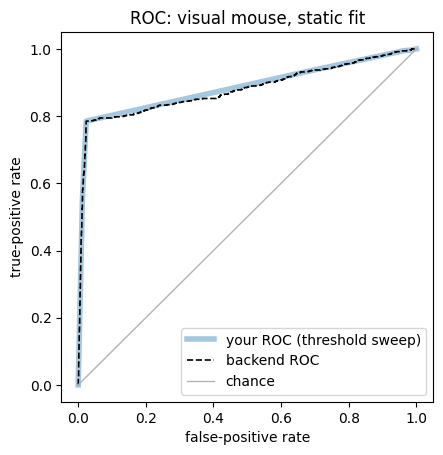

In [4]:
fpr, tpr = roc_curve(scores, y)
fpr_ref, tpr_ref = sb.roc_curve(scores, y)
plt.figure(figsize=(4.8, 4.8))
plt.plot(fpr, tpr, lw=4, alpha=0.4, label="your ROC (threshold sweep)")
plt.plot(fpr_ref, tpr_ref, "k--", lw=1.2, label="backend ROC")
plt.plot([0, 1], [0, 1], color="0.7", lw=1, label="chance")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("ROC: visual mouse, static fit"); plt.legend()
plt.show()

## 3. AUC — collapsing the curve to one number

Comparing whole curves is awkward; we'd like a single summary number. The **area
under the ROC curve** (AUC) is that number, and it has a strikingly concrete
meaning:

> **AUC is the probability that the model gives a higher score to a randomly
> chosen bout image than to a randomly chosen quiet image.**

Picture drawing one image where a bout happened and one where it didn't, at
random, and asking: did the model score the bout one higher? The AUC is the
fraction of such pairs it gets in the *right order*. So **0.5** means it orders
pairs no better than a coin flip (the diagonal), and **1.0** means it ranks
*every* bout image above *every* quiet one (the top-left corner). Notice what AUC
does **not** care about: only the *ordering* of the scores matters, never their
exact values — it is a pure measure of discrimination.

### Computing it without checking every pair

Comparing every bout image to every quiet image is $n_+ \times n_-$ comparisons —
millions of them here. There is a shortcut through **ranks**. Sort all $n$ scores
from smallest to largest and give each one its rank ($1$ for the smallest, up to
$n$ for the largest). Take a single bout image whose rank is $r$: then exactly
$r-1$ images score below it. Summing the ranks of *all* bout images gives a total
$R_+$, which counts — for every bout image — how many images sit below it. But
some of those lower-ranked images are *other bout images*, which we should not be
counting. The number of bout-below-bout pairs is always
$1 + 2 + \dots + n_+ = n_+(n_+{+}1)/2$. Subtract it, and what remains is exactly
the number of **quiet images ranked below bout images** — the pairs we wanted.
Divide by the total number of pairs $n_+ n_-$:

$$\text{AUC} = \frac{R_+ - n_+(n_+{+}1)/2}{n_+\, n_-}.$$

(Statisticians call the numerator the Mann–Whitney $U$ statistic.) Before trusting
this, let's check it against brute-force pair-counting on a tiny example:

In [5]:
# 2 bout images (y=1) and 3 quiet ones (y=0), with made-up scores:
toy_scores = np.array([0.2, 0.4, 0.5, 0.6, 0.8])
toy_y      = np.array([0,   1,   0,   1,   0  ], dtype=bool)

# brute force: over all (bout, quiet) pairs, fraction the model orders correctly
pos = toy_scores[toy_y]; neg = toy_scores[~toy_y]
correct = [s_pos > s_neg for s_pos in pos for s_neg in neg]
print("brute-force AUC:", np.mean(correct))

# rank formula
ranks = rankdata(toy_scores)
R_pos, n_pos, n_neg = ranks[toy_y].sum(), toy_y.sum(), (~toy_y).sum()
print("rank-formula AUC:", (R_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

brute-force AUC: 0.5
rank-formula AUC: 0.5


Same answer — the formula is just the pair-counting done cleverly.

**Exercise 2.** Complete `auc_score` using that formula. `rankdata` (imported at
the top) returns the ranks and, importantly, **averages ties**: many images share
an identical design row here and so get an identical score, and averaging their
ranks is what keeps the count correct.

> **Check / unstuck.** Expect **AUC ≈ 0.88**, matching the backend. Stuck? Use
> `sb.auc_score(scores, y)`.

In [6]:
def auc_score(scores, y):
    y = np.asarray(y).astype(bool)
    n_pos, n_neg = y.sum(), (~y).sum()
    ranks = rankdata(scores)
    return (ranks[y].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

In [7]:
print("your AUC     :", round(auc_score(scores, y), 3))
print("backend AUC  :", round(sb.auc_score(scores, y), 3))

your AUC     : 0.88
backend AUC  : 0.88


## 4. Cross-validation: an honest score

That AUC was measured on the **same data** we fit — it's optimistic. The fair
test is prediction on **held-out** images. We split the session into contiguous
time blocks, fit on all but one, score the one left out, and repeat. (Contiguous
blocks, not random images, so neighboring images don't leak between train and
test.)

**Exercise 3.** Fill in the fit-and-score step inside the cross-validation loop.

> **Check / unstuck.** Cross-validated AUC ≈ **0.87**, just under the in-sample 0.88.
> Stuck? Use `sb.cross_val_auc(X, y)`.

In [8]:
def cross_val_auc(X, y, n_folds=5):
    n = len(y)
    folds = np.array_split(np.arange(n), n_folds)
    aucs = []
    for i in range(n_folds):
        test = folds[i]
        train = np.setdiff1d(np.arange(n), test)
        w = sb.fit_static(X[train], y[train])
        aucs.append(auc_score(sb.predict_prob(w, X[test]), y[test]))
    return np.array(aucs)

In [9]:
cv = cross_val_auc(X, y)
print(f"in-sample AUC       : {auc_score(scores, y):.3f}")
print(f"cross-validated AUC : {cv.mean():.3f} +/- {cv.std():.3f}")

in-sample AUC       : 0.880
cross-validated AUC : 0.870 +/- 0.019


The two are close here — the static model has few parameters, so it barely
overfits. Cross-validation matters more once models get flexible (the dynamic
model in Notebook 7 can chase noise if its smoothing is too loose).

## 5. AUC across many mice

Finally, the population view behind Figure 2A. The static model predicts
**static** mice well. On **dynamic** mice — whose strategy drifts — one fixed
weight vector trained on early images predicts late images poorly, so its
held-out AUC sags. That gap is the quantitative case for the dynamic model.

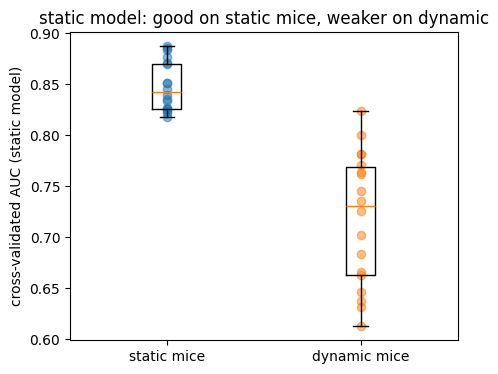

static mice : 0.848
dynamic mice: 0.718


In [10]:
def mouse_cv_auc(archetype, seed):
    X, y, _ = get_Xy(sb.make_mouse(archetype, seed=seed))
    return cross_val_auc(X, y).mean()

static_aucs = [mouse_cv_auc(a, s) for s in range(6) for a in ["visual", "timing", "mixed"]]
dynamic_aucs = [mouse_cv_auc("dynamic", s) for s in range(18)]

plt.figure(figsize=(5, 4))
plt.boxplot([static_aucs, dynamic_aucs])
plt.xticks([1, 2], ["static mice", "dynamic mice"])
plt.scatter(np.ones(len(static_aucs)), static_aucs, alpha=0.5)
plt.scatter(2 * np.ones(len(dynamic_aucs)), dynamic_aucs, alpha=0.5)
plt.ylabel("cross-validated AUC (static model)")
plt.title("static model: good on static mice, weaker on dynamic")
plt.show()
print(f"static mice : {np.mean(static_aucs):.3f}")
print(f"dynamic mice: {np.mean(dynamic_aucs):.3f}")

## Wrap-up

You now have an honest yardstick for a behavioral model: the ROC curve, its AUC,
and a cross-validated estimate that doesn't flatter the fit. You also saw the
static model's held-out performance drop on dynamic mice — foreshadowing.

**Next (Notebook 5):** the AUC says *how well* the model predicts, but not *which
strategies* it's using. For that we turn to model evidence and ablation — and on
our single-strategy mice the answer will be reassuringly obvious.